In [119]:
import pandas as pd
import numpy as np
import math
import random
import matplotlib.pyplot as plt
from DCmatch import Match

In [120]:
### FUNCTIONS
def getNewError(mean: float, var: float):
    return np.random.normal(mean, math.sqrt(var))

def generateAttackStrengths(init: int, n: int, betas: list, errorMean: float, errorVar: float):
    alphas = [init for i in range(5)]
    for i in range(n):
        nextStrength = 0
        for j in range(len(betas)):
            nextStrength += alphas[-1 - j] * betas[j]
        nextStrength += getNewError(errorMean, errorVar)
        nextStrength = abs(nextStrength)
        alphas.append(nextStrength)
    return alphas

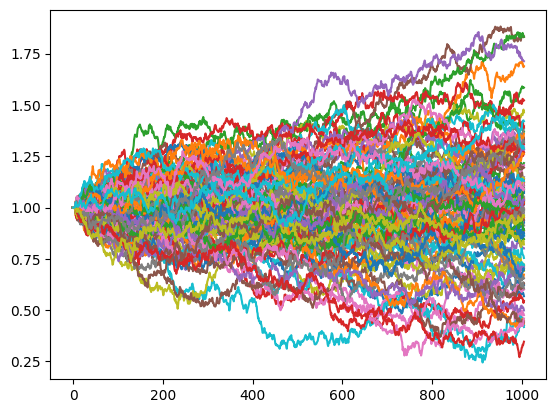

In [121]:
### TEST CELL ###
init = 1
fig, ax  = plt.subplots()
for i in range(100):
    ax.plot(generateAttackStrengths(init, 1000, [1], 0.0, 0.0001))

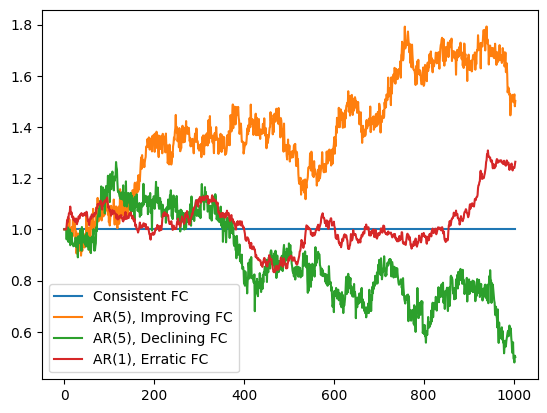

In [134]:
np.random.seed(1008)
fig, ax  = plt.subplots()

attack1 = generateAttackStrengths(1, 1000, [0.5, 0.5], 0, 0)
attack2 = generateAttackStrengths(1, 1000, [0.35, 0.25, 0.2, 0.1, 0.1], 0.001, 0.001)
attack3 = generateAttackStrengths(1, 1000, [0.35, 0.25, 0.2, 0.1, 0.1], -0.001, 0.001)
attack4 = generateAttackStrengths(1, 1000, [1], 0, 0.0001)

ax.plot(attack1, label="Consistent FC")
ax.plot(attack2, label="AR(5), Improving FC")
ax.plot(attack3, label="AR(5), Declining FC")
ax.plot(attack4, label="AR(1), Erratic FC")
ax.legend()
plt.savefig("dynamicStrengths.pdf")

In [123]:
teams = [i for i in range(4)]
attackStrengths = [attack1, attack2, attack3, attack4]
defenceStrengths = [0.6, 0.6, 0.6, 0.6]

homeAdv = 1.2
rho = 0.5
maxGoals = 7

results = pd.DataFrame(columns=["HomeTeam", "AwayTeam", "HomeGoals", "AwayGoals", "alphaH_t", "betaH_t", "alphaA_t", "betaA_t"])

# simulate 1000 games between the teams at random
for i in range(1000):
    # choose two of the teams at random
    currentTeams = random.sample(teams, 2)
    homeTeam = currentTeams[0]
    awayTeam = currentTeams[1]
    
    # simulate match
    currentMatch = Match(attackStrengths[homeTeam][i], defenceStrengths[homeTeam], attackStrengths[awayTeam][i], defenceStrengths[awayTeam],
                        homeAdv, rho, maxGoals)
    scoreline = currentMatch.simulateResult()
    
    # add match to match DataFrame
    results.loc[i] = [homeTeam, awayTeam, scoreline[0], scoreline[1], 0, 0, 0, 0]

In [124]:
results.head()

,HomeTeam,AwayTeam,HomeGoals,AwayGoals,alphaH_t,betaH_t,alphaA_t,betaA_t
0,3,2,1,0,0,0,0,0
1,1,2,0,0,0,0,0,0
2,2,0,2,1,0,0,0,0
3,0,3,2,0,0,0,0,0
4,1,2,0,1,0,0,0,0


In [125]:
def phi(t):
    return np.exp(-0.0065*t)

def logLikelihood(parameters, data):
    numTeams = int((len(parameters) - 2) // 2)
    
    attackStrengths = np.array(parameters[0:numTeams])
    defenceStrengths = np.array(parameters[numTeams:numTeams*2])

    homeAdv = parameters[-2]
    rho = parameters[-1]
    t = data.index[-1]
    ll = 0

    for tk, row in data.iterrows():
        i = int(row["HomeTeam"])
        j = int(row["AwayTeam"])
        x = int(row["HomeGoals"])
        y = int(row["AwayGoals"])

        lamd = attackStrengths[i] * defenceStrengths[j] * homeAdv
        mu = attackStrengths[j] * defenceStrengths[i]

        ll += (np.log(Match.tauFunc(lamd, mu, rho, x, y) + 1e-7) - lamd + x*np.log(lamd) - mu + y*np.log(mu)) * phi(t - tk)
    
    return -ll

In [126]:
from scipy.optimize import minimize
def getNewEstimates(results: pd.DataFrame):
    rng = np.random.default_rng(123)
    init_att = rng.uniform(0.3, 1.2, size=4)
    init_def = rng.uniform(0.3, 1.2, size=4)
    init_home = 1.1
    init_rho = 0.0

    init = np.concatenate([init_att, init_def, [init_home, init_rho]])

    bounds = [(1,1)] + [(1e-6, None)] * (7) + [(1e-6, None), (-0.99, 0.99)]

    result = minimize(
        logLikelihood,
        init,
        args=(results,),
        bounds=bounds,
        options={'maxiter': 10000, 'disp': True},
    )
    return result.x

In [127]:
estimatesAtTimeT = []
for i in range(20):
    estimatesAtTimeT.append(getNewEstimates(results.head(n=300+i*35)))

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            9     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.18573D+02    |proj g|=  1.01816D+02

At iterate    1    f=  2.69631D+02    |proj g|=  1.34294D+00

At iterate    2    f=  2.56811D+02    |proj g|=  1.44655D+00

At iterate    3    f=  2.49425D+02    |proj g|=  9.19371D+00

At iterate    4    f=  2.47213D+02    |proj g|=  8.71743D+00

At iterate    5    f=  2.46214D+02    |proj g|=  2.88417D+00

At iterate    6    f=  2.45525D+02    |proj g|=  2.70578D+00

At iterate    7    f=  2.44301D+02    |proj g|=  5.17330D+00

At iterate    8    f=  2.44003D+02    |proj g|=  1.80372D+00

At iterate    9    f=  2.43937D+02    |proj g|=  7.45794D-01

At iterate   10    f=  2.43914D+02    |proj g|=  9.72983D-01

At iterate   11    f=  2.43894D+02    |proj g|=  6.57005D-01

At iterate   12    f=  2.43877D+02    |proj g|=  4.06848D-01

At iterate   13    f=  2.4

In [147]:
team1EstAttack = []
team1EstDefence = []
team2EstAttack = []
team2EstDefence = []
team3EstAttack = []
team3EstDefence = []
team4EstAttack = []
team4EstDefence = []
rhoEst = []
homeAdvEst = []

for estimate in estimatesAtTimeT:
    team1EstAttack.append(estimate[0])
    team2EstAttack.append(estimate[1])
    team3EstAttack.append(estimate[2])
    team4EstAttack.append(estimate[3])

    team1EstDefence.append(estimate[4])
    team2EstDefence.append(estimate[5])
    team3EstDefence.append(estimate[6])
    team4EstDefence.append(estimate[7])

    rhoEst.append(estimate[9])
    homeAdvEst.append(estimate[8])

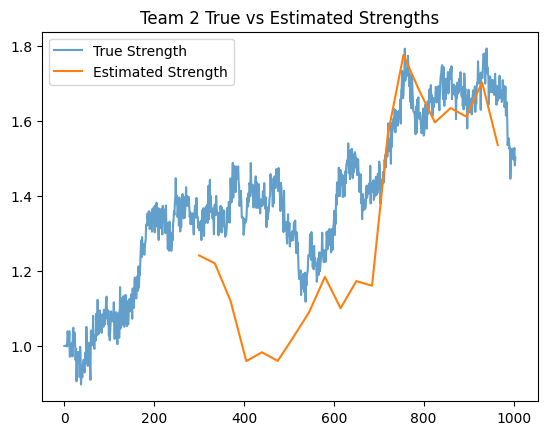

In [140]:
fig, ax = plt.subplots()
xsEst = [300 + 35*i for i in range(20)]
xs = [i for i in range(1005)]
ax.plot(xs, attack2, label="True Strength", alpha=0.7)
ax.plot(xsEst, team2EstAttack, label="Estimated Strength")
ax.set_title("Team 2 True vs Estimated Strengths")
ax.legend()
plt.savefig("team2.pdf")

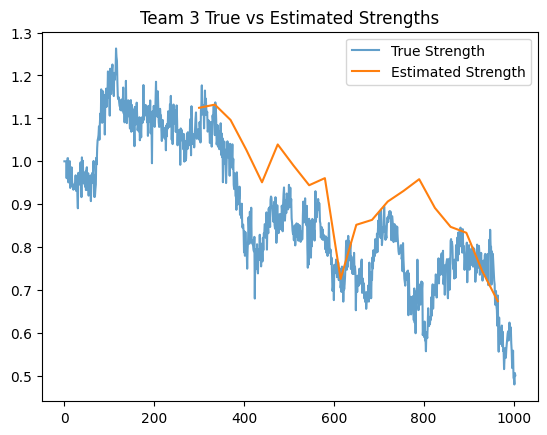

In [141]:
fig, ax = plt.subplots()
xsEst = [300 + 35*i for i in range(20)]
xs = [i for i in range(1005)]
ax.plot(xs, attack3, label="True Strength", alpha=0.7)
ax.plot(xsEst, team3EstAttack, label="Estimated Strength")
ax.set_title("Team 3 True vs Estimated Strengths")
ax.legend()
plt.savefig("team3.pdf")

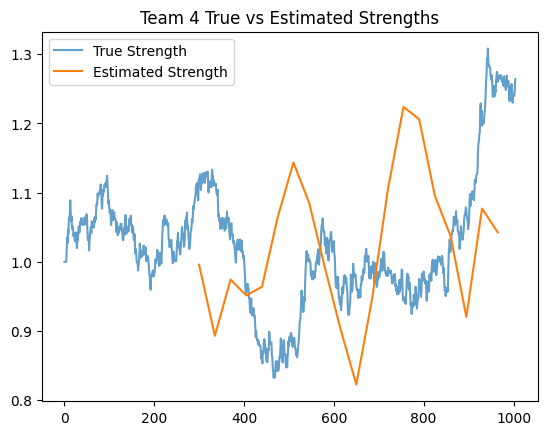

In [142]:
fig, ax = plt.subplots()
xsEst = [300 + 35*i for i in range(20)]
xs = [i for i in range(1005)]
ax.plot(xs, attack4, label="True Strength", alpha=0.7)
ax.plot(xsEst, team4EstAttack, label="Estimated Strength")
ax.set_title("Team 4 True vs Estimated Strengths")
ax.legend()
plt.savefig("team4.pdf")

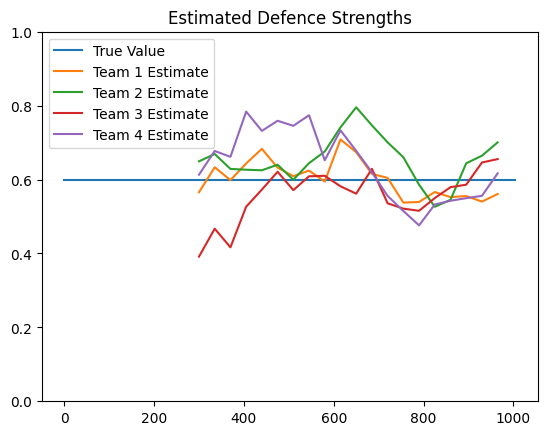

In [144]:
fig, ax = plt.subplots()
xsEst = [300 + 35*i for i in range(20)]
xs = [i for i in range(1005)]
ax.plot(xs, [0.6 for i in range(1005)], label="True Value")
ax.plot(xsEst, team1EstDefence, label="Team 1 Estimate")
ax.plot(xsEst, team2EstDefence, label="Team 2 Estimate")
ax.plot(xsEst, team3EstDefence, label="Team 3 Estimate")
ax.plot(xsEst, team4EstDefence, label="Team 4 Estimate")
ax.legend()
ax.set_title("Estimated Defence Strengths")
ax.set_ybound(0, 1)
plt.savefig("defenceEst.pdf")

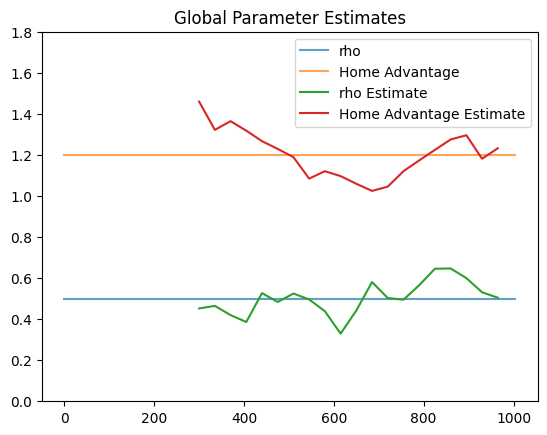

In [150]:
fig, ax = plt.subplots()
xsEst = [300 + 35*i for i in range(20)]
xs = [i for i in range(1005)]
ax.plot(xs, [0.5 for i in range(1005)], label="rho", alpha=0.7)
ax.plot(xs, [1.2 for i in range(1005)], label="Home Advantage", alpha=0.7)
ax.plot(xsEst, rhoEst, label="rho Estimate")
ax.plot(xsEst, homeAdvEst, label="Home Advantage Estimate")
ax.legend()
ax.set_title("Global Parameter Estimates")
ax.set_ybound(0, 1.8)
plt.savefig("rhoAndHome.pdf")